# Data Preprocessing

Clean and prepare text data for modeling

In [1]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import re
import json
from tqdm import tqdm

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Dataset and Splits

In [2]:
dataset = load_from_disk("../github_issues_dataset")
df = pd.DataFrame(dataset['train'])

with open('../artifacts/splits.json', 'r') as f:
    splits = json.load(f)

with open('../artifacts/label_mappings.json', 'r') as f:
    label_mappings = json.load(f)

print(f"Dataset: {len(df):,} issues")
print(f"Train: {len(splits['train']):,}")
print(f"Val: {len(splits['val']):,}")
print(f"Test: {len(splits['test']):,}")

Dataset: 114,073 issues
Train: 91,258
Val: 11,407
Test: 11,408


## 2. Text Cleaning Functions

In [3]:
def clean_text(text):
    """Clean GitHub issue text"""
    if pd.isna(text) or text == '':
        return ''
    
    text = str(text)
    
    # Remove code blocks
    text = re.sub(r'```[\s\S]*?```', ' [CODE] ', text)
    text = re.sub(r'`[^`\n]+`', ' [CODE] ', text)
    
    # Remove URLs
    text = re.sub(r'https?://\S+', ' [URL] ', text)
    
    # Remove markdown images
    text = re.sub(r'!\[.*?\]\(.*?\)', ' ', text)
    
    # Keep markdown links text only
    text = re.sub(r'\[(.+?)\]\(.+?\)', r'\1', text)
    
    # Remove markdown formatting
    text = re.sub(r'#{1,6}\s', '', text)
    text = re.sub(r'\*{1,2}(.+?)\*{1,2}', r'\1', text)
    text = re.sub(r'_{1,2}(.+?)_{1,2}', r'\1', text)
    
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def combine_title_body(title, body):
    """Combine title and body with special tokens"""
    clean_title = clean_text(title)
    clean_body = clean_text(body)
    
    # Repeat title for emphasis
    if clean_title and clean_body:
        return f"[TITLE] {clean_title} [TITLE] {clean_title} [SEP] {clean_body}"
    elif clean_title:
        return f"[TITLE] {clean_title} [TITLE] {clean_title}"
    elif clean_body:
        return f"[SEP] {clean_body}"
    else:
        return ""

print("✓ Cleaning functions defined")

✓ Cleaning functions defined


## 3. Test Cleaning on Samples

In [4]:
print("Before cleaning:")
sample = df.iloc[0]
print(f"Title: {sample['title'][:100]}")
print(f"Body: {str(sample['body'])[:200]}...")

print("\nAfter cleaning:")
cleaned = combine_title_body(sample['title'], sample['body'])
print(cleaned[:300])

Before cleaning:
Title: Output file size with -s or -g
Body: Was: http://bitbucket.org/rg3/youtube-dl/issue/141/

If the file size was outputted it would be possible to script youtube-dl to test if the current video the the harddrive is in the best possible qua...

After cleaning:
[TITLE] Output file size with -s or -g [TITLE] Output file size with -s or -g [SEP] Was: [URL] If the file size was outputted it would be possible to script youtube-dl to test if the current video the the harddrive is in the best possible quality. It happens that Youtube re-encode videos, and with h


## 4. Apply Preprocessing to All Data

In [5]:
print("Preprocessing all issues...")
tqdm.pandas()

df['text'] = df.progress_apply(
    lambda row: combine_title_body(row['title'], row['body']), 
    axis=1
)

print(f"\n✓ Preprocessing complete")
print(f"Empty texts: {(df['text'] == '').sum()}")

Preprocessing all issues...


100%|██████████| 114073/114073 [00:28<00:00, 3935.99it/s]


✓ Preprocessing complete
Empty texts: 0


## 5. Encode Labels

In [6]:
df['priority_label'] = df['priority'].map(label_mappings['priority'])
df['severity_label'] = df['severity'].map(label_mappings['severity'])

print("Label encoding:")
print("\nPriority:")
print(df[['priority', 'priority_label']].drop_duplicates().sort_values('priority_label'))
print("\nSeverity:")
print(df[['severity', 'severity_label']].drop_duplicates().sort_values('severity_label'))

Label encoding:

Priority:
   priority  priority_label
1       low               0
0    medium               1
12     high               2

Severity:
   severity  severity_label
2     Minor               0
1     Major               1
0  Critical               2


## 6. Text Length After Preprocessing

Text length after preprocessing:
count    114073.000000
mean        176.759715
std         205.881695
min           4.000000
25%          84.000000
50%         137.000000
75%         217.000000
max       26298.000000
Name: text_len, dtype: float64


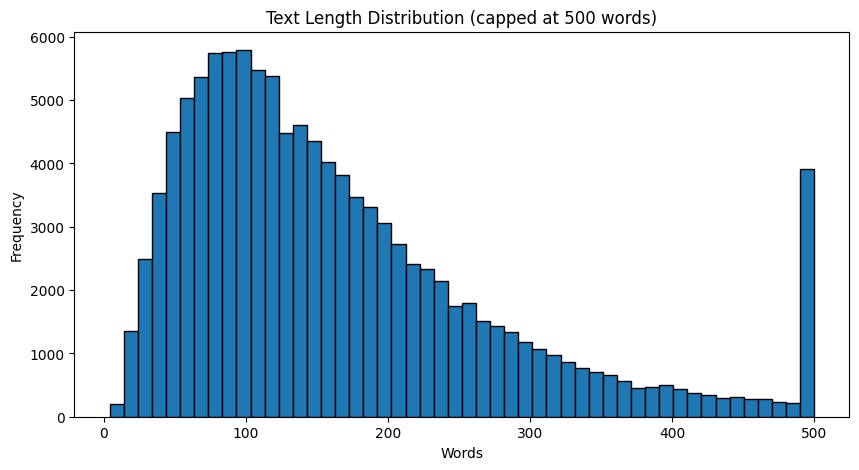

In [7]:
df['text_len'] = df['text'].apply(lambda x: len(x.split()))

print("Text length after preprocessing:")
print(df['text_len'].describe())

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(df['text_len'].clip(upper=500), bins=50, edgecolor='black')
plt.title('Text Length Distribution (capped at 500 words)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

## 7. Create Final Datasets

In [8]:
# Select relevant columns
processed_df = df[['id', 'repo', 'text', 'priority', 'priority_label', 
                    'severity', 'severity_label']].copy()

# Split into train/val/test
train_df = processed_df.iloc[splits['train']].reset_index(drop=True)
val_df = processed_df.iloc[splits['val']].reset_index(drop=True)
test_df = processed_df.iloc[splits['test']].reset_index(drop=True)

print(f"Train: {len(train_df):,}")
print(f"Val:   {len(val_df):,}")
print(f"Test:  {len(test_df):,}")

train_df.head()

Train: 91,258
Val:   11,407
Test:  11,408


,id,repo,text,priority,priority_label,severity,severity_label
0,2177538660,electron,[TITLE] [Bug]: Electron seems to ignore the mo...,low,0,Critical,2
1,1258478118,go,[TITLE] cmd/api: run api check on all ports [T...,low,0,Major,1
2,1041701477,pytorch,[TITLE] testjitfuserlegacy and testjitfuserte ...,medium,1,Critical,2
3,2409368685,go,[TITLE] net/http: TestServerKeepAlivesEnabled/...,low,0,Critical,2
4,1486533949,godot,"[TITLE] Type inference is ""weaker"" than no typ...",low,0,Critical,2


## 8. Save Processed Data

In [12]:
import os
os.makedirs('../data/processed', exist_ok=True)

train_df.to_csv('../data/processed/train.csv', index=False, escapechar='\\', quoting=1)
val_df.to_csv('../data/processed/val.csv', index=False, escapechar='\\', quoting=1)
test_df.to_csv('../data/processed/test.csv', index=False, escapechar='\\', quoting=1)

print("✓ Saved processed datasets:")
print("  - data/processed/train.csv")
print("  - data/processed/val.csv")
print("  - data/processed/test.csv")

✓ Saved processed datasets:
  - data/processed/train.csv
  - data/processed/val.csv
  - data/processed/test.csv


## Summary

**Preprocessing Steps**:
1. Removed code blocks → [CODE] token
2. Removed URLs → [URL] token
3. Cleaned markdown formatting
4. Combined title + body with special tokens
5. Encoded priority and severity labels

**Output**:
- Train: 91,258 issues
- Val: 11,407 issues
- Test: 11,408 issues

**Next**: Baseline model training